In [8]:
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [10]:
data = pd.read_csv('dhw_merge.csv')

In [12]:
data['date'] = pd.to_datetime(data.iloc[:,:4])
dataLen = int(len(data) * 0.7)

In [13]:
dhwData = data.drop(['YEAR', 'date'], axis=1)

##  For Scaling

In [14]:
dhw_X = dhwData.drop(['DHW'], axis=1)
dhw_Y = dhwData[['DHW']]

scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()  # [추가] Y 전용 스케일러

scaled_X = scaler_X.fit_transform(dhw_X)
scaled_Y = scaler_Y.fit_transform(dhw_Y)  # [추가] Y도 스케일링

new_dhw_X = pd.DataFrame(scaled_X, index=dhw_X.index, columns=dhw_X.columns)
new_dhw_Y = pd.DataFrame(scaled_Y, index=dhw_Y.index, columns=dhw_Y.columns)
new_dhw = pd.concat([new_dhw_X, new_dhw_Y], axis=1)

In [15]:
SEQ_LEN = 24

input_dhw = new_dhw.iloc[:-1]
target_dhw = new_dhw[['DHW']].iloc[1:]

trainX_dhw, testX_dhw, trainY_dhw, testY_dhw = train_test_split(
    input_dhw, target_dhw, test_size=0.3, shuffle=False, random_state=0
)

In [16]:
def buildDataSet(input, target, seqLength):
    xdata, ydata = [], []
    for i in range(len(input) - seqLength):
        tx = input.iloc[i:i + seqLength]
        ty = target.iloc[i + seqLength - 1]
        xdata.append(tx)
        ydata.append(ty)
    return np.array(xdata), np.array(ydata)

trainx_dhw, trainy_dhw = buildDataSet(trainX_dhw, trainY_dhw, SEQ_LEN)
testx_dhw, testy_dhw = buildDataSet(testX_dhw, testY_dhw, SEQ_LEN)

print(f"Train shape: X={trainx_dhw.shape}, Y={trainy_dhw.shape}")
print(f"Test  shape: X={testx_dhw.shape},  Y={testy_dhw.shape}")

Train shape: X=(20392, 24, 12), Y=(20392, 1)
Test  shape: X=(8727, 24, 12),  Y=(8727, 1)


In [17]:
trainx_dhw, trainy_dhw = buildDataSet(trainX_dhw, trainY_dhw, 24)
testx_dhw, testy_dhw = buildDataSet(testX_dhw, testY_dhw, 24)

In [18]:
def seq2seq_model_improved(input_shape):
    model_input = tf.keras.layers.Input(shape=input_shape)

    # CNN - kernel_size=3, 채널 32→64→128 순서로 점진적 확장
    conv1 = tf.keras.layers.Conv1D(32, kernel_size=3, padding='same', activation='swish')(model_input)
    conv1 = tf.keras.layers.BatchNormalization()(conv1)
    pool1 = tf.keras.layers.MaxPool1D(pool_size=2, strides=1, padding='same')(conv1)

    conv2 = tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='swish')(pool1)
    conv2 = tf.keras.layers.BatchNormalization()(conv2)
    pool2 = tf.keras.layers.MaxPool1D(pool_size=2, strides=1, padding='same')(conv2)

    conv3 = tf.keras.layers.Conv1D(128, kernel_size=3, padding='same', activation='swish')(pool2)
    conv3 = tf.keras.layers.BatchNormalization()(conv3)
    pool3 = tf.keras.layers.MaxPool1D(pool_size=2, strides=1, padding='same')(conv3)

    # 인코더 - LSTM 유닛 32→64→128 점진적 확장
    encoder_out1 = tf.keras.layers.LSTM(32, return_sequences=True, activation='tanh')(pool3)
    encoder_out2 = tf.keras.layers.LSTM(64, return_sequences=True, activation='tanh')(encoder_out1)
    _, state_h, state_c = tf.keras.layers.LSTM(128, return_state=True, activation='tanh')(encoder_out2)

    # 디코더 - RepeatVector로 진짜 Seq2Seq 구조
    decoder_input = tf.keras.layers.RepeatVector(input_shape[0])(state_h)
    decoder_out1 = tf.keras.layers.LSTM(128, return_sequences=True, activation='tanh')(
        decoder_input, initial_state=[state_h, state_c]
    )
    decoder_out2 = tf.keras.layers.LSTM(64, return_sequences=True, activation='tanh')(decoder_out1)
    decoder_out3 = tf.keras.layers.LSTM(32, return_sequences=True, activation='tanh')(decoder_out2)

    # 출력 - linear activation (에너지 소비량은 항상 양수)
    flatten = tf.keras.layers.Flatten()(decoder_out3)
    flatten = tf.keras.layers.Dropout(0.2)(flatten)
    model_output = tf.keras.layers.Dense(1, activation=None)(flatten)

    return tf.keras.models.Model(model_input, model_output)

In [19]:
model = seq2seq_model_improved(input_shape=(SEQ_LEN, trainx_dhw.shape[2]))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 32)    │      1,184 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 24, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 32)    │     20,608 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     24,832 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 128),     │     98,816 │ lstm_1[0][0]      │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 128)   │          0 │ lstm_2[0][1]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 24, 128)   │    131,584 │ repeat_vector[0]… │
│                     │                   │            │ lstm_2[0][1],     │
│                     │                   │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 24, 64)    │     49,408 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 24, 32)    │     12,416 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 768)       │          0 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 768)       │          0 │ flatten[0][0]   

 Total params: 371,425 (1.42 MB)

 Trainable params: 370,977 (1.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
earlystopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    monitor='val_loss',        # [수정] moniter → monitor
    filepath='dhw_source.keras',
    save_best_only=True,       # [추가] best 모델만 저장
    verbose=1
)

In [21]:
model.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adamax(learning_rate=3e-4, clipnorm=1.0),
    metrics=['mae']
)

In [22]:
hist = model.fit(
    trainx_dhw, trainy_dhw,
    epochs=200,
    batch_size=1024,
    validation_split=0.1,      # [추가] 학습 중 검증셋 모니터링
    callbacks=[earlystopping, checkpoint]
)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 0.1676 - mae: 0.1676
Epoch 1: val_loss improved from None to 0.10807, saving model to dhw_source.keras

Epoch 1: finished saving model to dhw_source.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - loss: 0.1195 - mae: 0.1195 - val_loss: 0.1081 - val_mae: 0.1081
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - loss: 0.0658 - mae: 0.0658
Epoch 2: val_loss improved from 0.10807 to 0.10612, saving model to dhw_source.keras

Epoch 2: finished saving model to dhw_source.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 292ms/step - loss: 0.0596 - mae: 0.0596 - val_loss: 0.1061 - val_mae: 0.1061
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 0.0486 - mae: 0.0486
Epoch 3: val_loss improved from 0.10612 to 0.10510, saving model to dhw_source.keras

Epoch 3: finished saving model to dhw_source.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - loss: 0.0465 - mae: 0.0465 - val_loss: 0.1051 - val_mae: 0.1051
Epoch 4/200
18/18 ━━━━━━

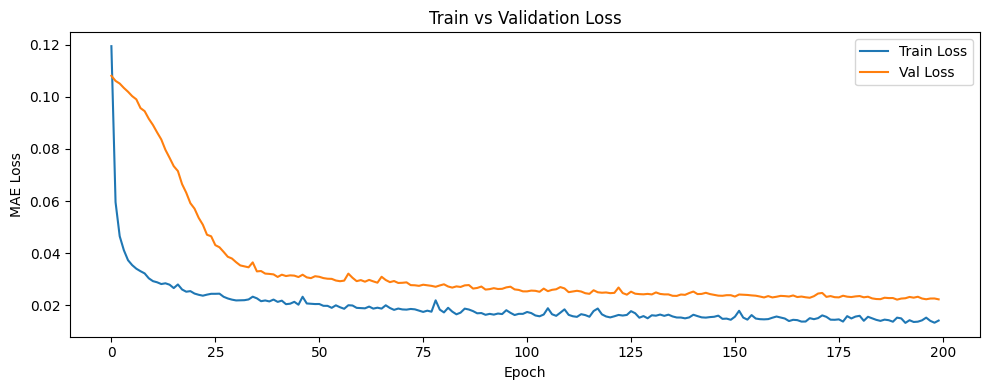

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
pred_scaled = model.predict(testx_dhw)
pred_scaled = np.reshape(pred_scaled, (-1, 1))

# [추가] inverse_transform으로 실제 단위 복원
pred = scaler_Y.inverse_transform(pred_scaled)
real = scaler_Y.inverse_transform(np.array(testy_dhw).reshape(-1, 1))

273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [25]:
print('=' * 40)
print(f"MAE  : {round(mean_absolute_error(real, pred), 4)}")
print(f"MSE  : {round(mean_squared_error(real, pred), 4)}")
print(f"RMSE : {round(np.sqrt(mean_squared_error(real, pred)), 4)}")
print(f"R2   : {round(r2_score(real, pred), 4)}")
print('=' * 40)

MAE  : 0.0544
MSE  : 0.0105
RMSE : 0.1026
R2   : 0.9846


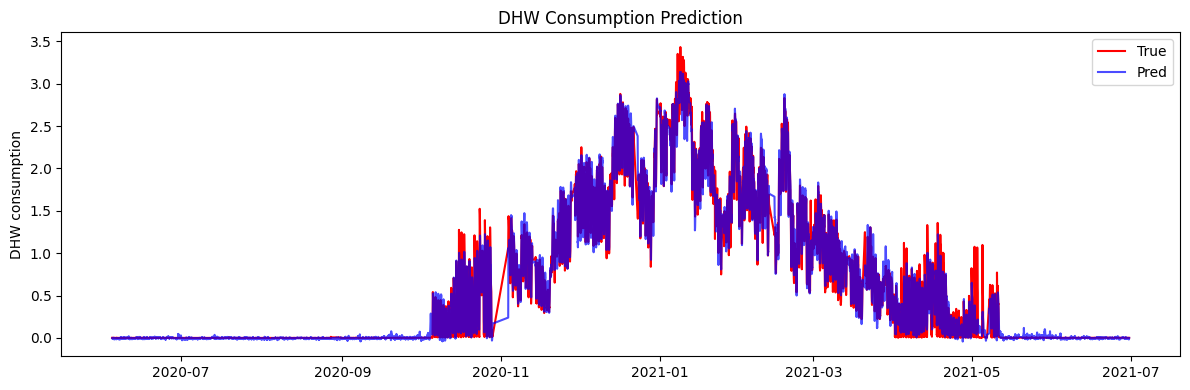

In [26]:
test_start_idx = len(trainX_dhw) + SEQ_LEN  # train 끝 + seqLength 오프셋
test_end_idx = test_start_idx + len(pred)
date = data['date'].iloc[test_start_idx:test_end_idx]

plt.figure(figsize=(12, 4))
plt.ylabel('DHW consumption', size=10)
plt.plot(date, real, color='red', label='True')
plt.plot(date, pred, color='blue', label='Pred', alpha=0.7)
plt.title('DHW Consumption Prediction')
plt.rc('font', size=10)
plt.legend()
plt.tight_layout()
plt.show()